# xBD Week 1 Exploration

Steps 6-12: load pre/post images, parse JSON labels, convert WKT polygons to coordinates, draw damage overlays, count class distribution, rasterize segmentation masks, and save examples.

In [25]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import week1_preprocessing
importlib.reload(week1_preprocessing)
from week1_preprocessing import *

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'visualizations'
SAMPLE_ID = 'hurricane-florence_00000018'

## Step 6 - Load and Display Images

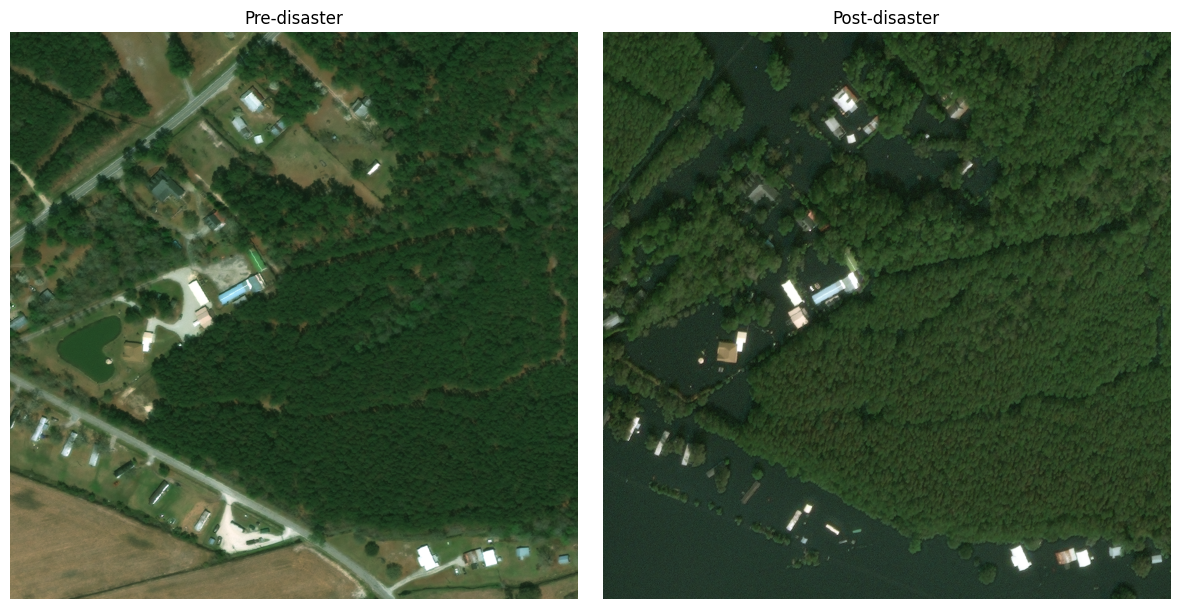

In [26]:
pre_path, post_path, label_path = image_pair_paths(DATA_DIR, SAMPLE_ID)

pre_image = load_image_rgb(pre_path)
post_image = load_image_rgb(post_path)

display_pre_post(pre_image, post_image)

## Steps 7-8 - Read JSON Labels and Parse Polygon Coordinates

In [27]:
features = read_label_features(label_path)
polygons = parse_polygons(features)

print(f'Buildings in JSON: {len(features)}')
print(f'Parsed polygon groups: {len(polygons)}')
print('First feature subtype:', features[0]['properties']['subtype'])
print('First polygon NumPy shape:', polygons[0][1][0].shape)

Buildings in JSON: 47
Parsed polygon groups: 47
First feature subtype: major-damage
First polygon NumPy shape: (7, 1, 2)


## Step 9 - Draw Polygons on Images

Color key: green = no damage, yellow = minor damage, orange = major damage, red = destroyed.

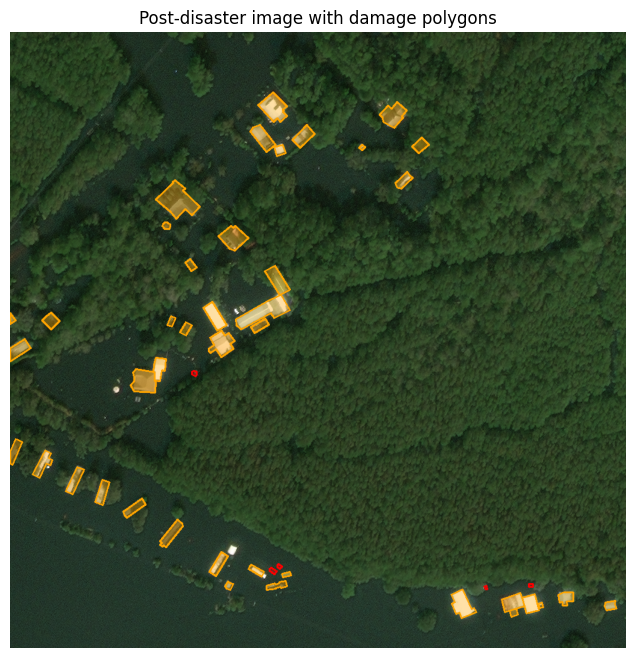

In [28]:
overlay = draw_polygons(post_image, polygons)

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.axis('off')
plt.title('Post-disaster image with damage polygons');

## Step 10 - Create Damage Statistics

In [29]:
counts = damage_statistics(features)
print('Damage Class\tCount')
for damage_class in ['no-damage', 'minor-damage', 'major-damage', 'destroyed', 'un-classified']:
    print(f'{damage_class}\t{counts.get(damage_class, 0)}')

Damage Class	Count
no-damage	0
minor-damage	0
major-damage	42
destroyed	5
un-classified	0


## Step 11 - Build Segmentation Masks

Mask values: 0 = background, 1 = no damage, 2 = minor damage, 3 = major damage, 4 = destroyed.

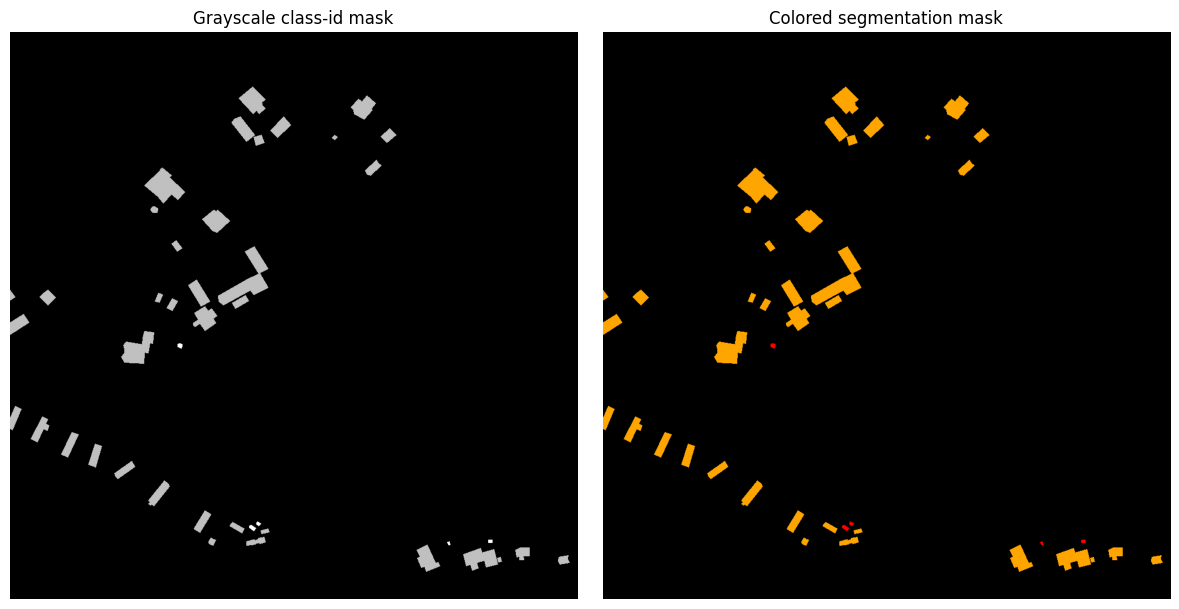

In [30]:
mask = create_damage_mask(post_image.shape, polygons)
color_mask = mask_to_color(mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mask, cmap='gray', vmin=0, vmax=4)
axes[0].set_title('Grayscale class-id mask')
axes[0].axis('off')
axes[1].imshow(color_mask)
axes[1].set_title('Colored segmentation mask')
axes[1].axis('off')
plt.tight_layout();

## Step 12 - Save Visualization Examples

In [31]:
save_visualization_examples(SAMPLE_ID, pre_image, post_image, overlay, mask, OUTPUT_DIR)
save_statistics_csv(counts, OUTPUT_DIR / f'{SAMPLE_ID}_damage_statistics.csv')

print(f'Saved examples to: {OUTPUT_DIR}')

Saved examples to: C:\Users\amins\Documents\python\Damage-detection-project\outputs\visualizations


## Week 1 Extras - Dataset Statistics, Integrity Checks, and Boxes

In [32]:
# Full dataset class distribution for reports.
dataset_counts = dataset_damage_statistics(DATA_DIR, split='train')
save_statistics_csv(dataset_counts, OUTPUT_DIR / 'train_dataset_damage_statistics.csv')

print('Class\tTotal Buildings')
for damage_class in ['no-damage', 'minor-damage', 'major-damage', 'destroyed', 'un-classified']:
    print(f'{damage_class}\t{dataset_counts.get(damage_class, 0)}')

C:\Users\amins\Documents\python\Damage-detection-project\src\week1_preprocessing.py:80: UserWarning: [week1] No pixel-space features found in: C:\Users\amins\Documents\python\Damage-detection-project\data\train\labels\guatemala-volcano_00000008_post_disaster.json
  warn(f"No pixel-space features found in: {label_path}")
C:\Users\amins\Documents\python\Damage-detection-project\src\week1_preprocessing.py:80: UserWarning: [week1] No pixel-space features found in: C:\Users\amins\Documents\python\Damage-detection-project\data\train\labels\hurricane-florence_00000058_post_disaster.json
  warn(f"No pixel-space features found in: {label_path}")
C:\Users\amins\Documents\python\Damage-detection-project\src\week1_preprocessing.py:80: UserWarning: [week1] No pixel-space features found in: C:\Users\amins\Documents\python\Damage-detection-project\data\train\labels\hurricane-florence_00000093_post_disaster.json
  warn(f"No pixel-space features found in: {label_path}")
C:\Users\amins\Documents\python\

Class	Total Buildings
no-damage	117426
minor-damage	14980
major-damage	14161
destroyed	13227
un-classified	2993


C:\Users\amins\Documents\python\Damage-detection-project\src\week1_preprocessing.py:80: UserWarning: [week1] No pixel-space features found in: C:\Users\amins\Documents\python\Damage-detection-project\data\train\labels\socal-fire_00000537_post_disaster.json
  warn(f"No pixel-space features found in: {label_path}")
C:\Users\amins\Documents\python\Damage-detection-project\src\week1_preprocessing.py:80: UserWarning: [week1] No pixel-space features found in: C:\Users\amins\Documents\python\Damage-detection-project\data\train\labels\socal-fire_00000538_post_disaster.json
  warn(f"No pixel-space features found in: {label_path}")
C:\Users\amins\Documents\python\Damage-detection-project\src\week1_preprocessing.py:80: UserWarning: [week1] No pixel-space features found in: C:\Users\amins\Documents\python\Damage-detection-project\data\train\labels\socal-fire_00000540_post_disaster.json
  warn(f"No pixel-space features found in: {label_path}")
C:\Users\amins\Documents\python\Damage-detection-projec

In [33]:
# Bounding boxes prepare the labels for YOLO / Faster R-CNN style experiments.
boxes = polygon_bounding_boxes(polygons)
save_bounding_boxes_csv(boxes, OUTPUT_DIR / f'{SAMPLE_ID}_bounding_boxes.csv')

boxes[:5]

[{'damage_class': 'major-damage',
  'xmin': 988,
  'ymin': 945,
  'xmax': 1008,
  'ymax': 961},
 {'damage_class': 'major-damage',
  'xmin': 911,
  'ymin': 931,
  'xmax': 936,
  'ymax': 953},
 {'damage_class': 'destroyed',
  'xmin': 862,
  'ymin': 917,
  'xmax': 869,
  'ymax': 922},
 {'damage_class': 'major-damage',
  'xmin': 851,
  'ymin': 934,
  'xmax': 879,
  'ymax': 966},
 {'damage_class': 'major-damage',
  'xmin': 878,
  'ymin': 948,
  'xmax': 886,
  'ymax': 957}]

## One-Command Pipeline

The same workflow is available as a script:

```bash
python src/week1_preprocessing.py --sample-id guatemala-volcano_00000000 --dataset-stats --overlay-alpha 0.35
```